In [1]:
from src.ArtifficialTrainDataGenerator import ArtifficialTrainDataGenerator 
import matplotlib.pyplot as plt
import numpy as np


X, y = ArtifficialTrainDataGenerator.generate_artificial_data(10, max_elements_per_sample=3, set_percentages=True, cache_element_samples=False)


In [2]:
from src.FeatureEnhancer import FeatureEnhancer

X = FeatureEnhancer.process_spectra(X)

100%|██████████| 1/1 [00:00<00:00, 3675.99it/s]


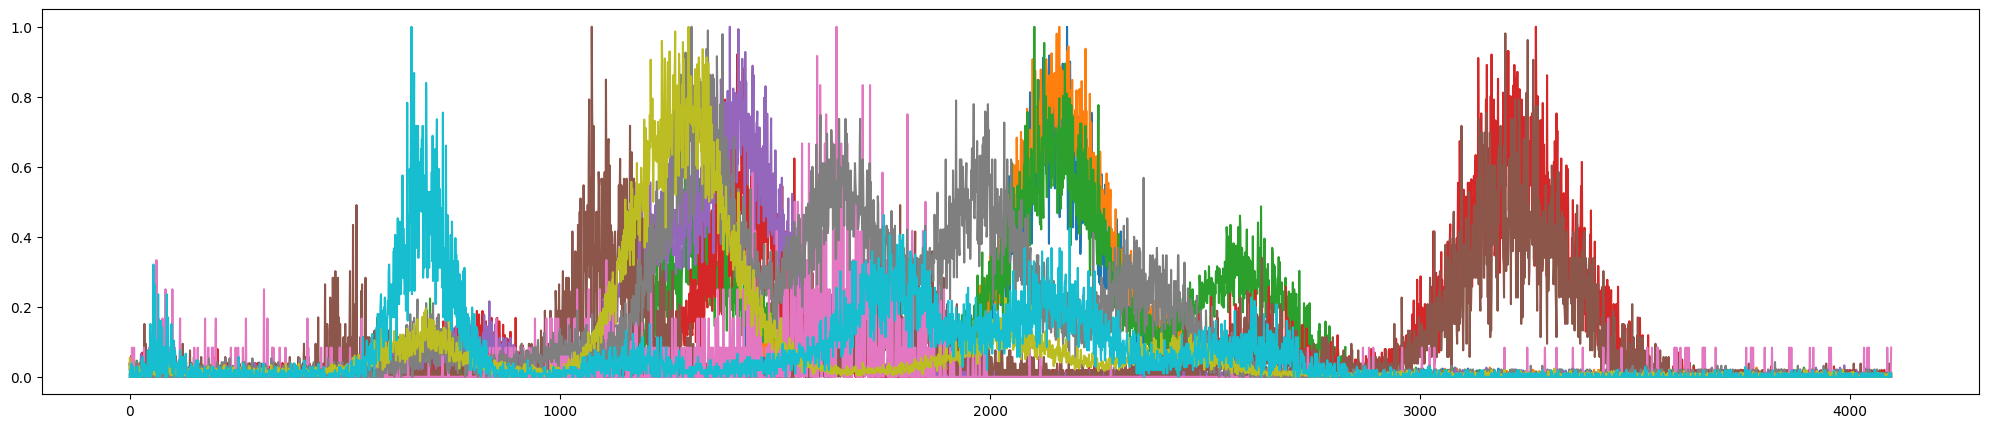

In [3]:
plt.figure(figsize=(25, 5))
n =0 
for i in range(10):
    plt.plot( X[i+n], label = f"{np.round(y[i+n], 2)}")

In [4]:
# np.save("data/artificial/X.npy", X)
# np.save("data/artificial/y.npy", y)

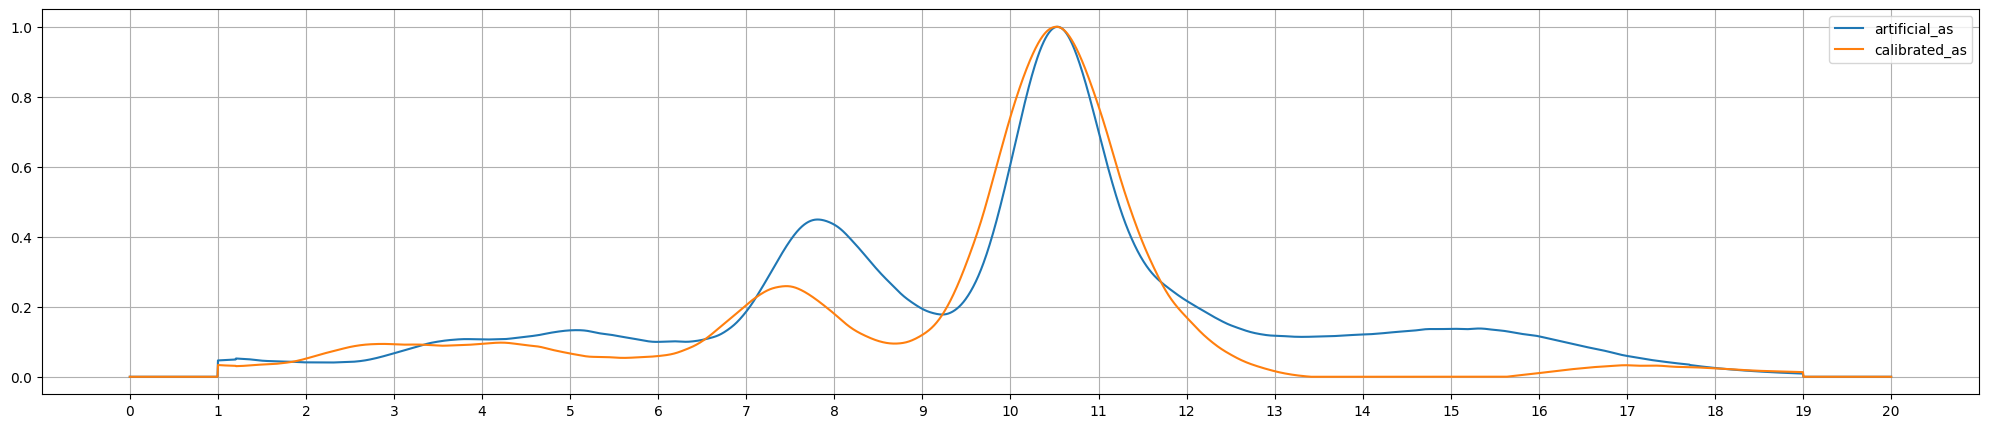

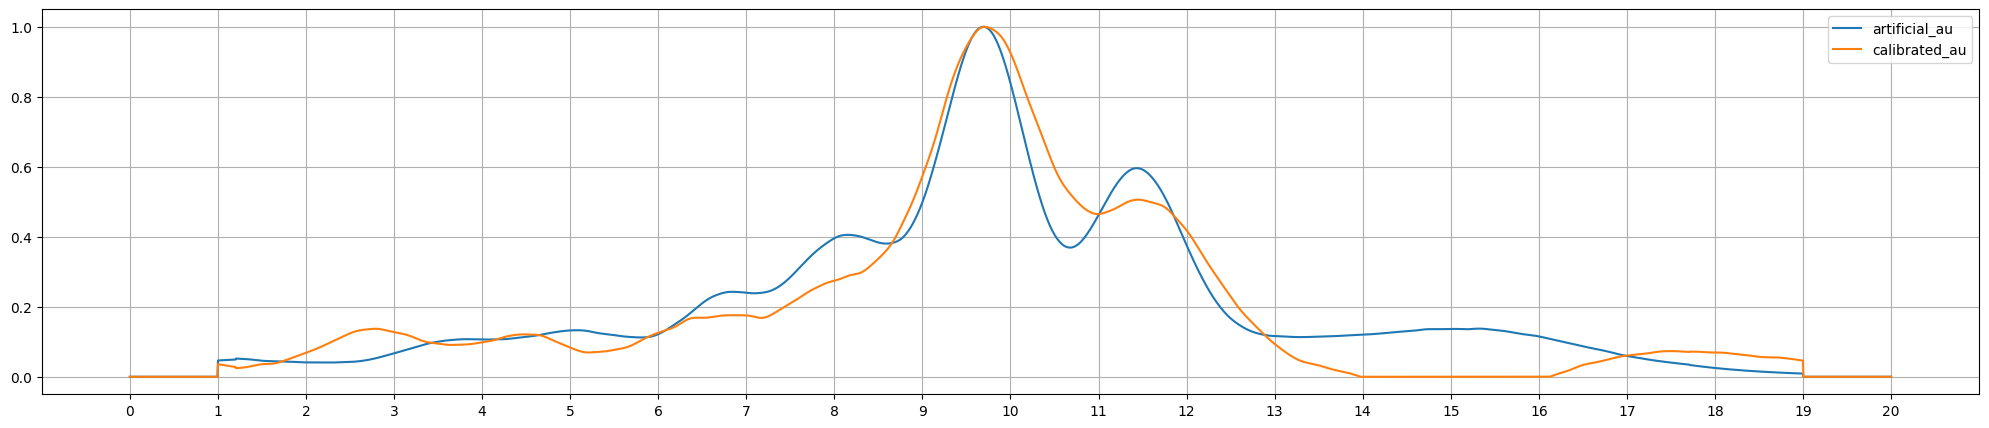

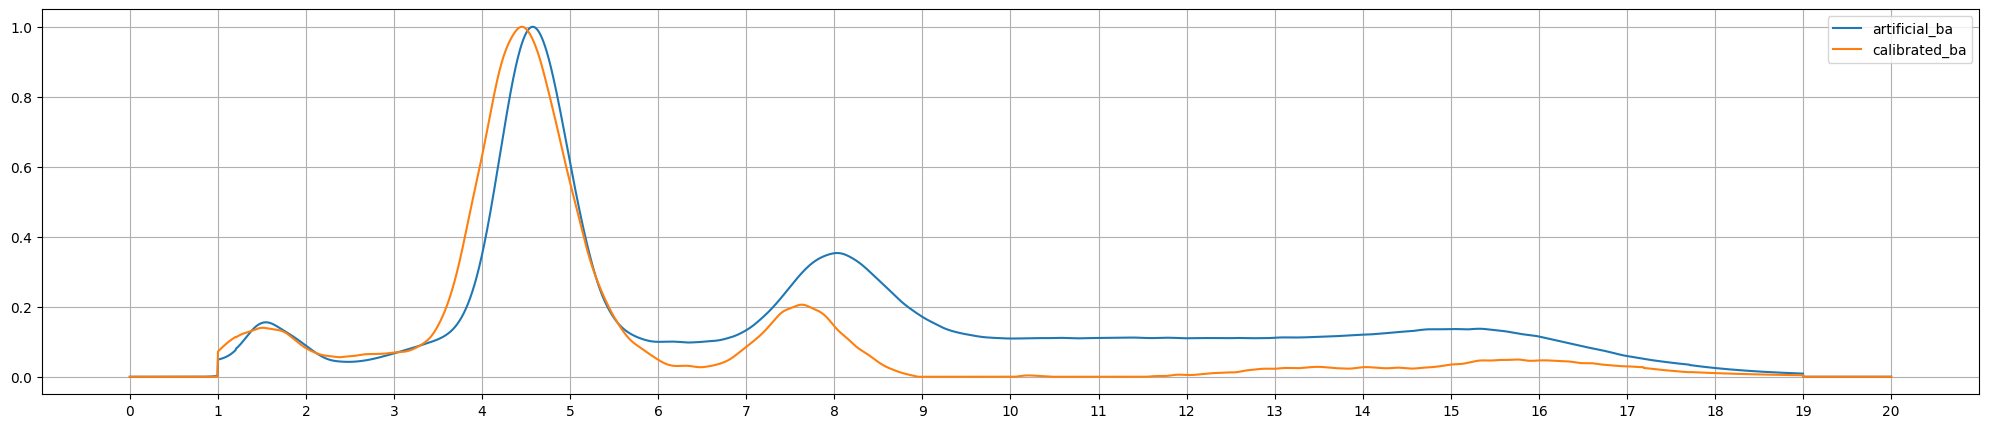

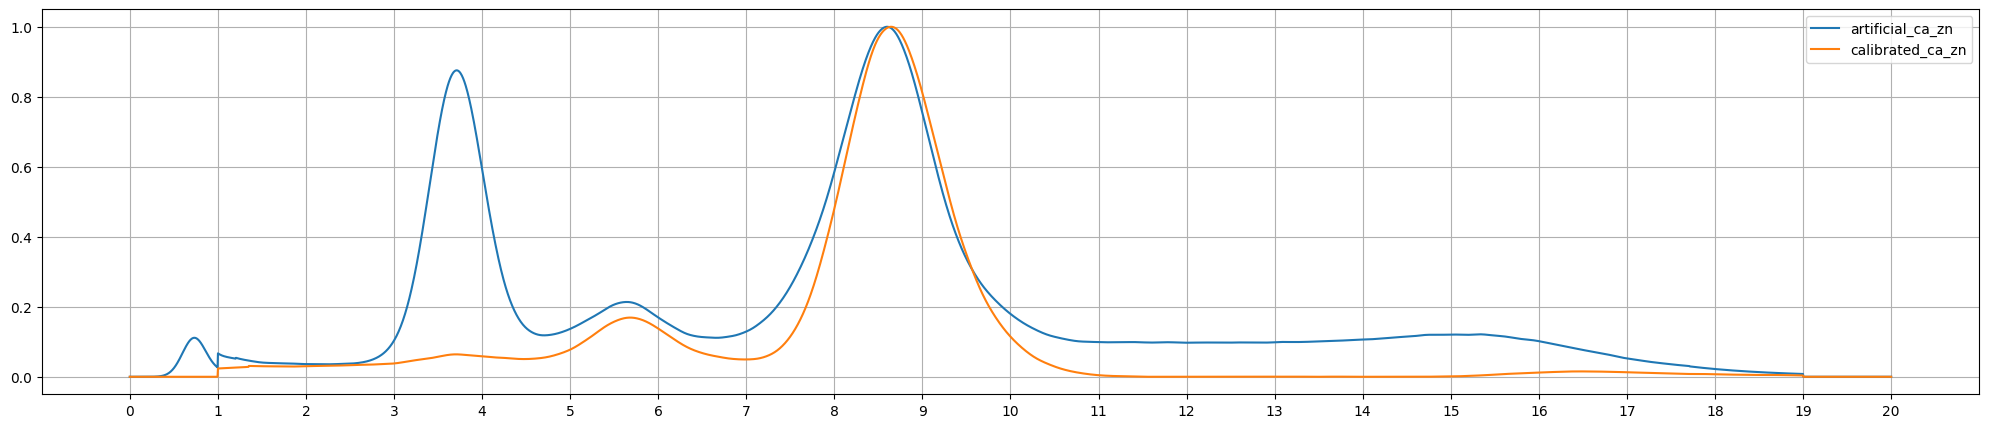

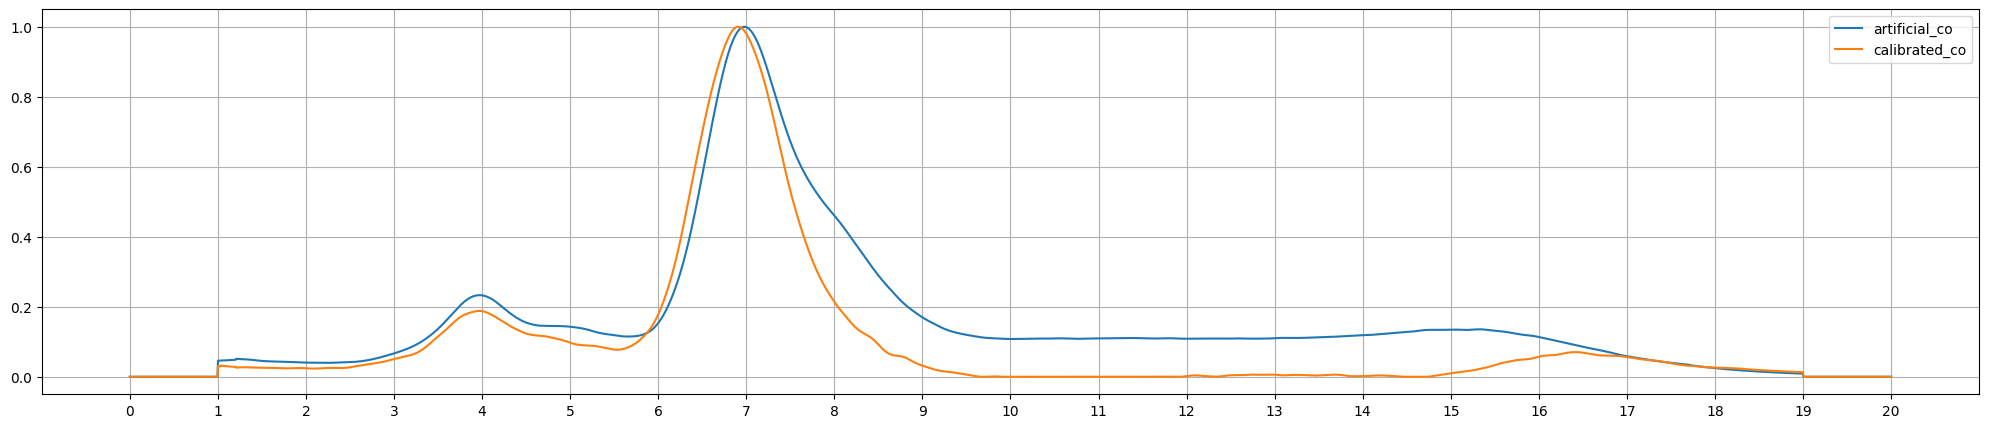

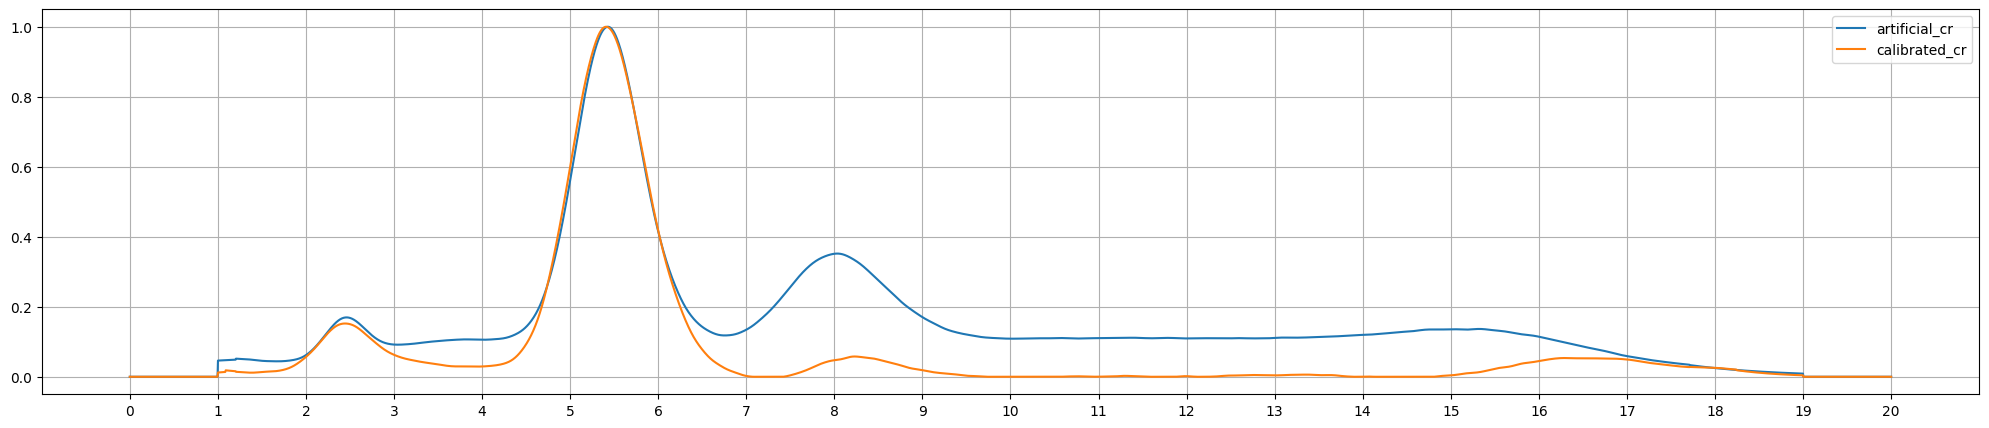

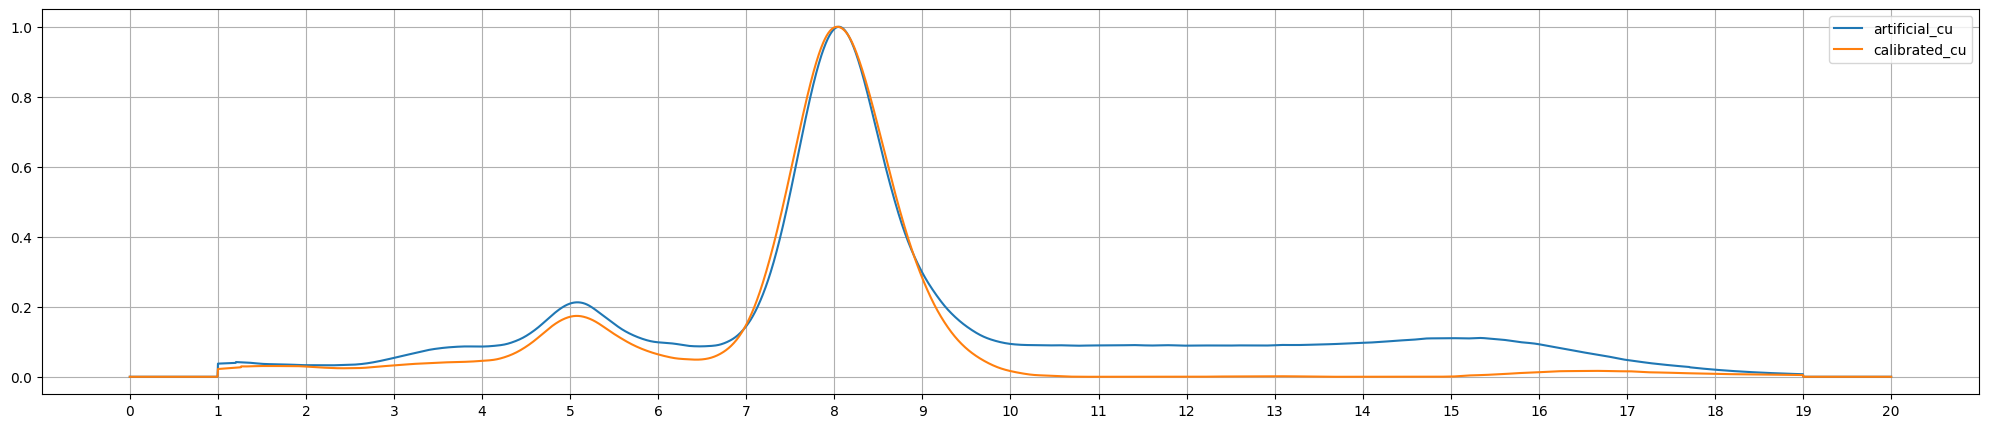

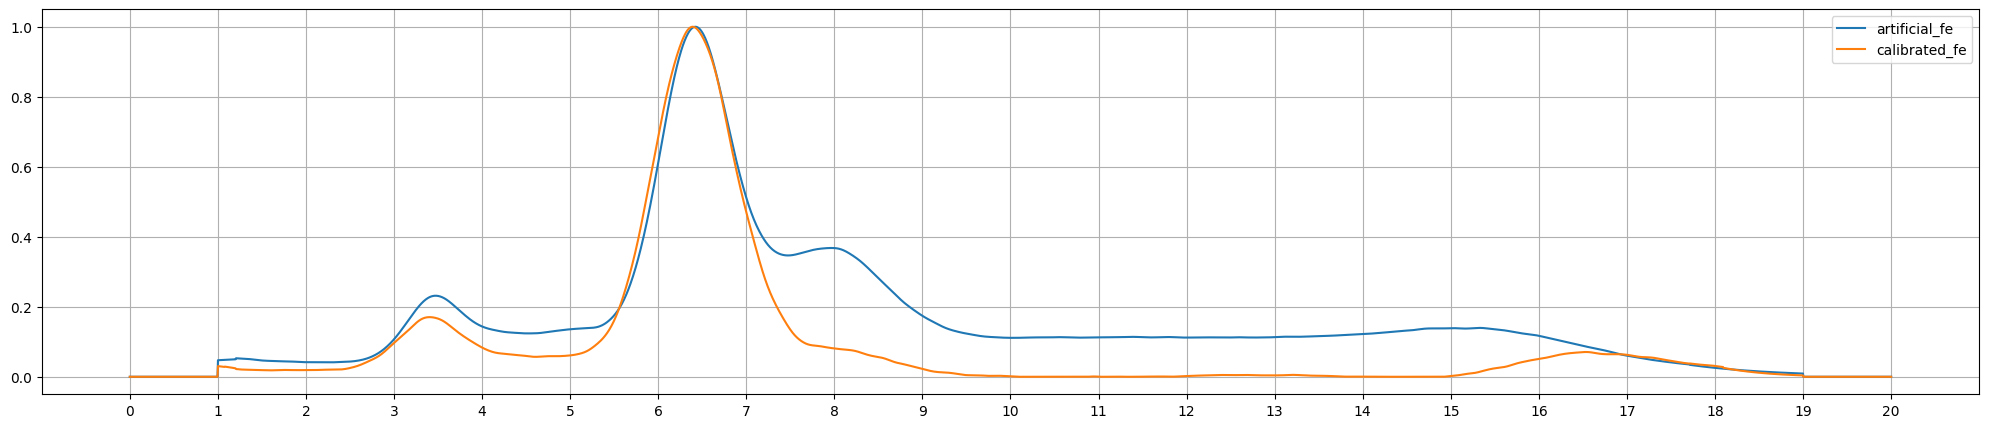

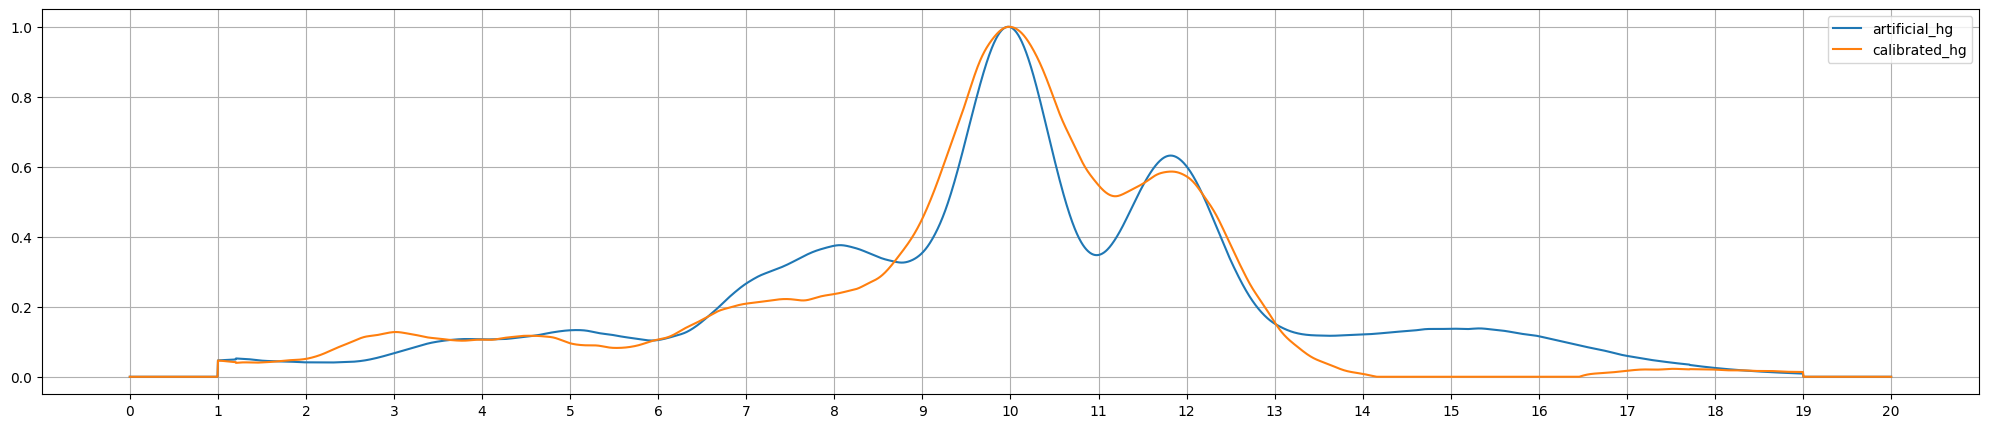

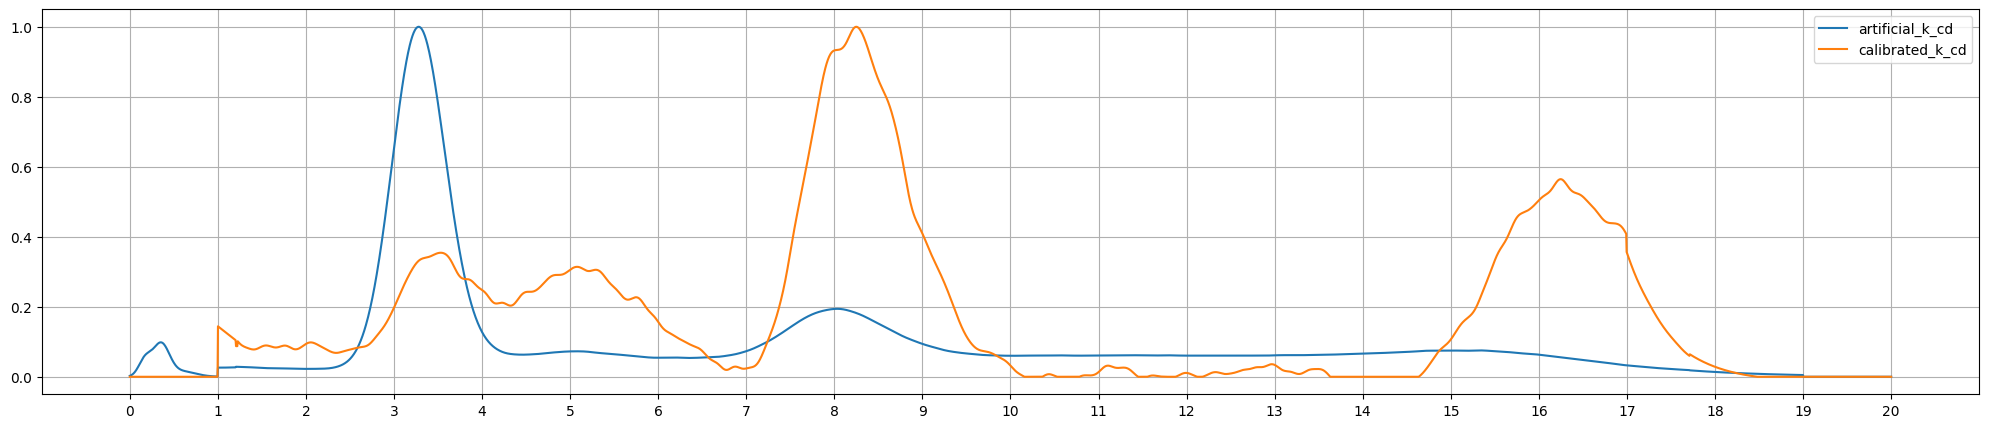

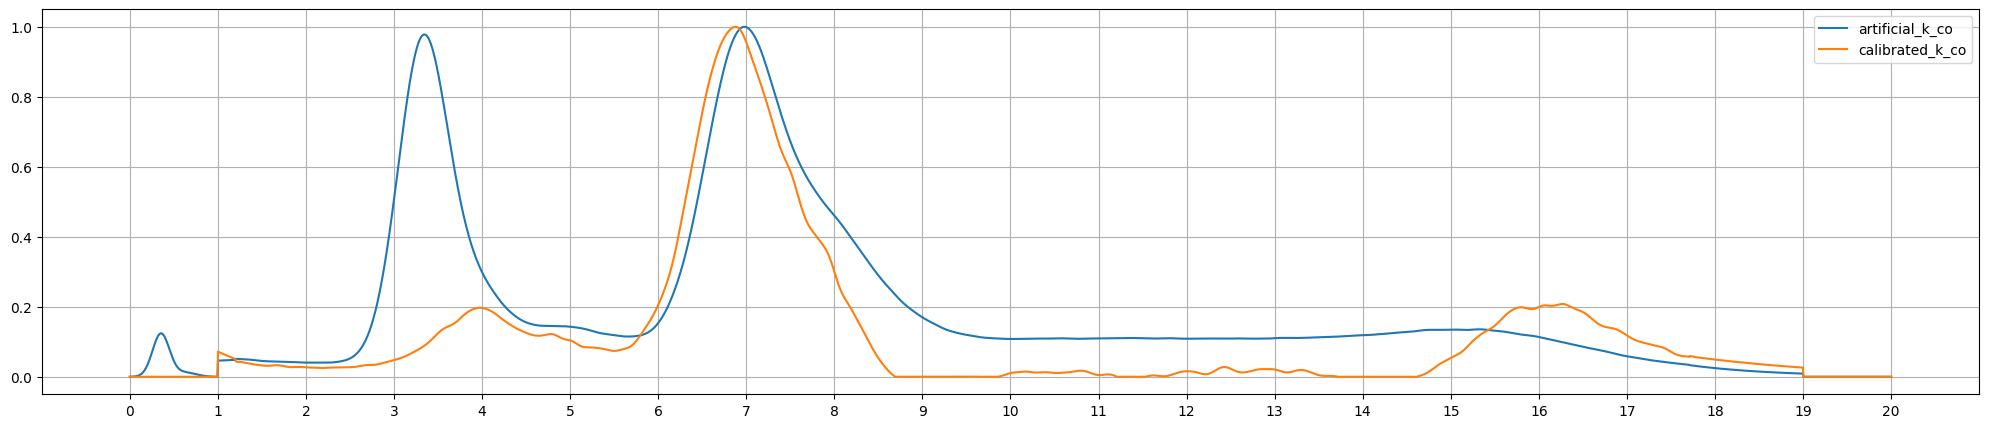

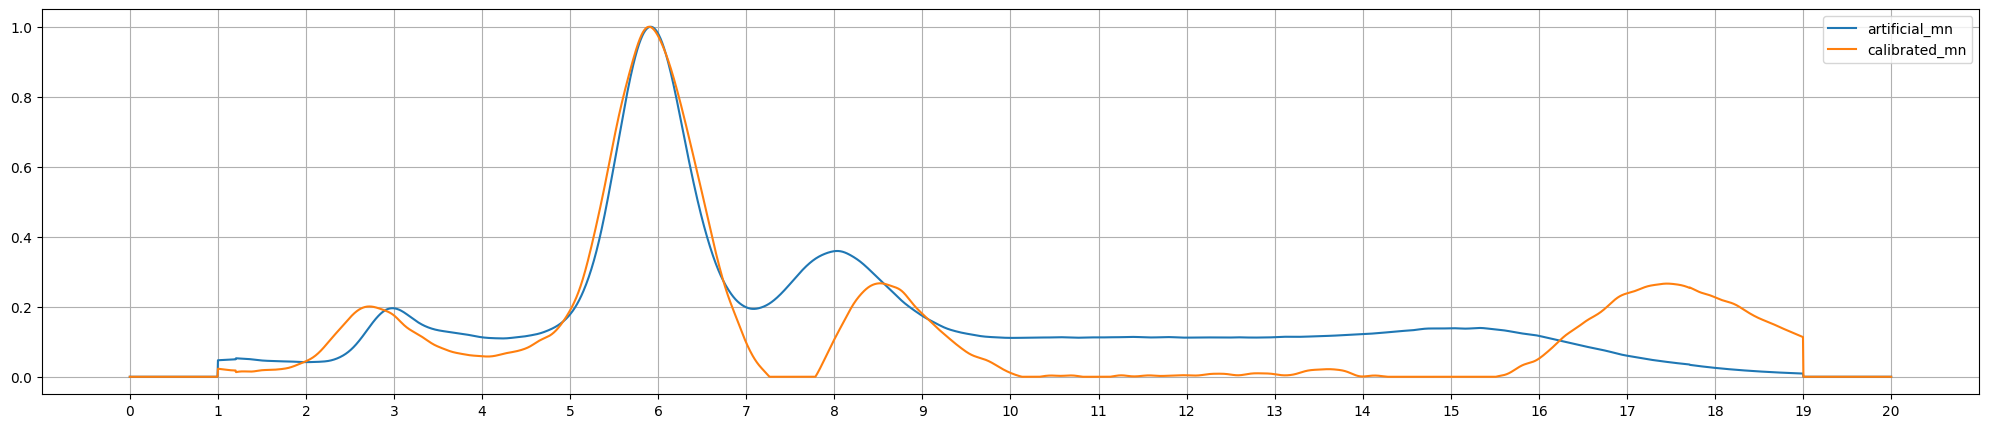

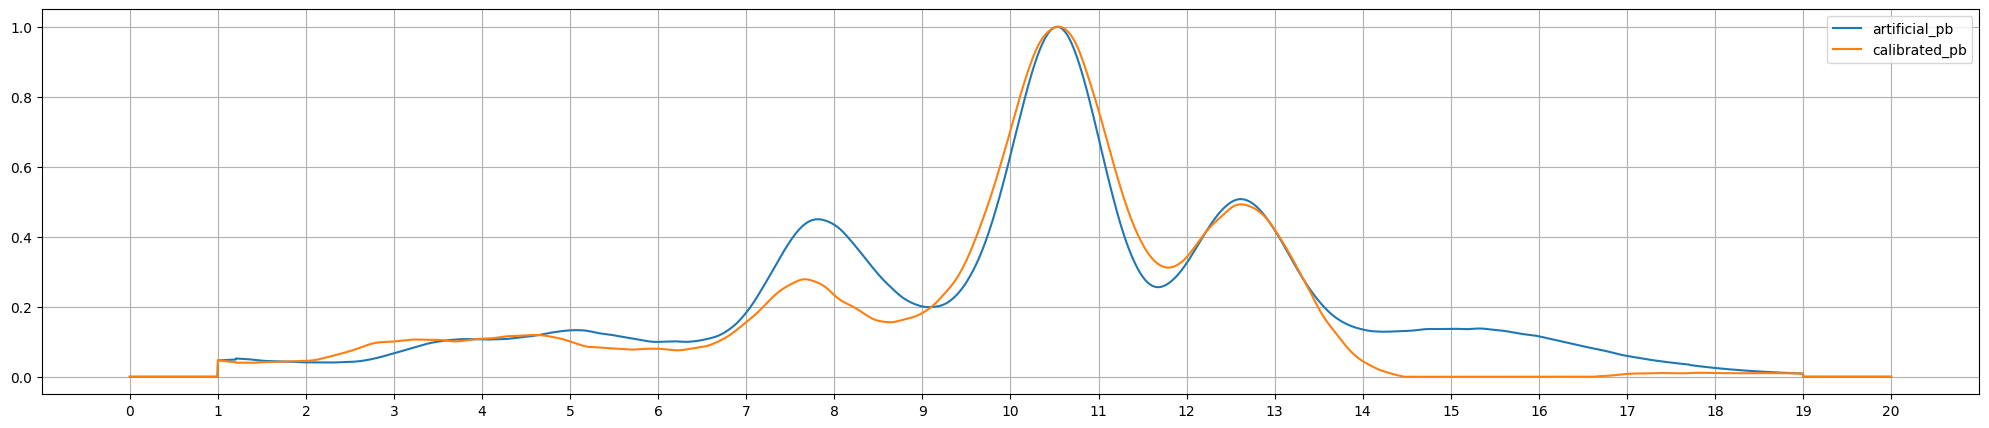

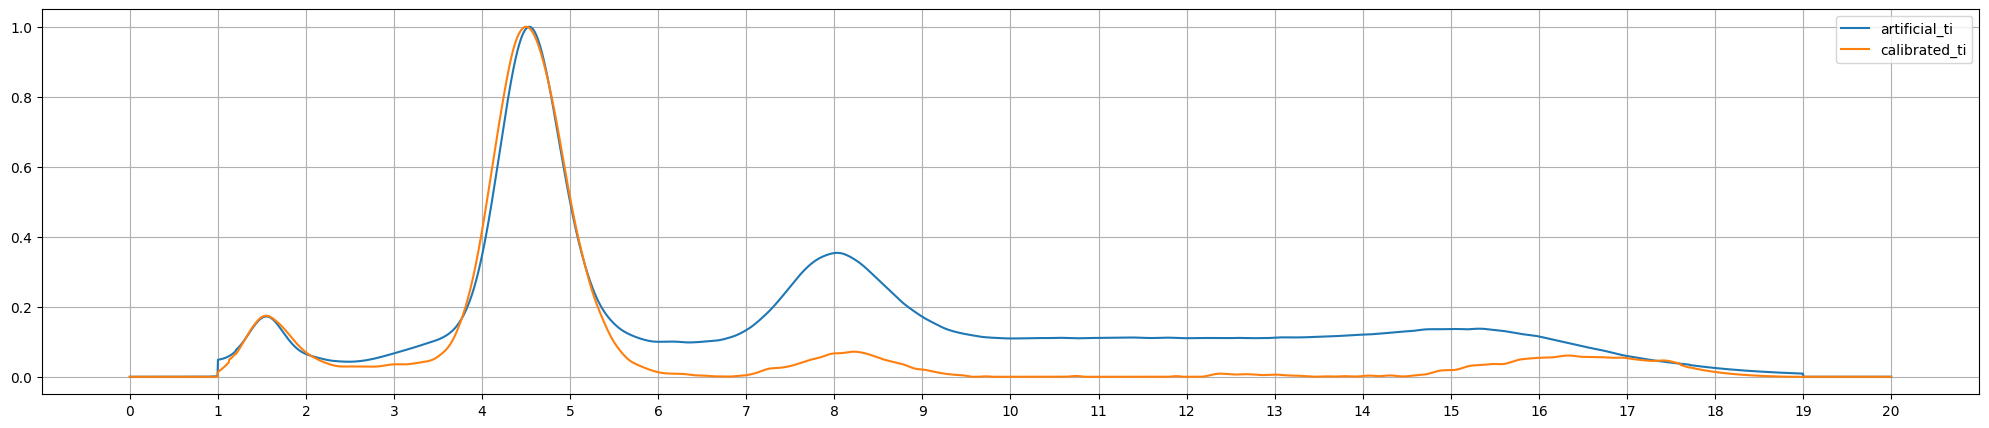

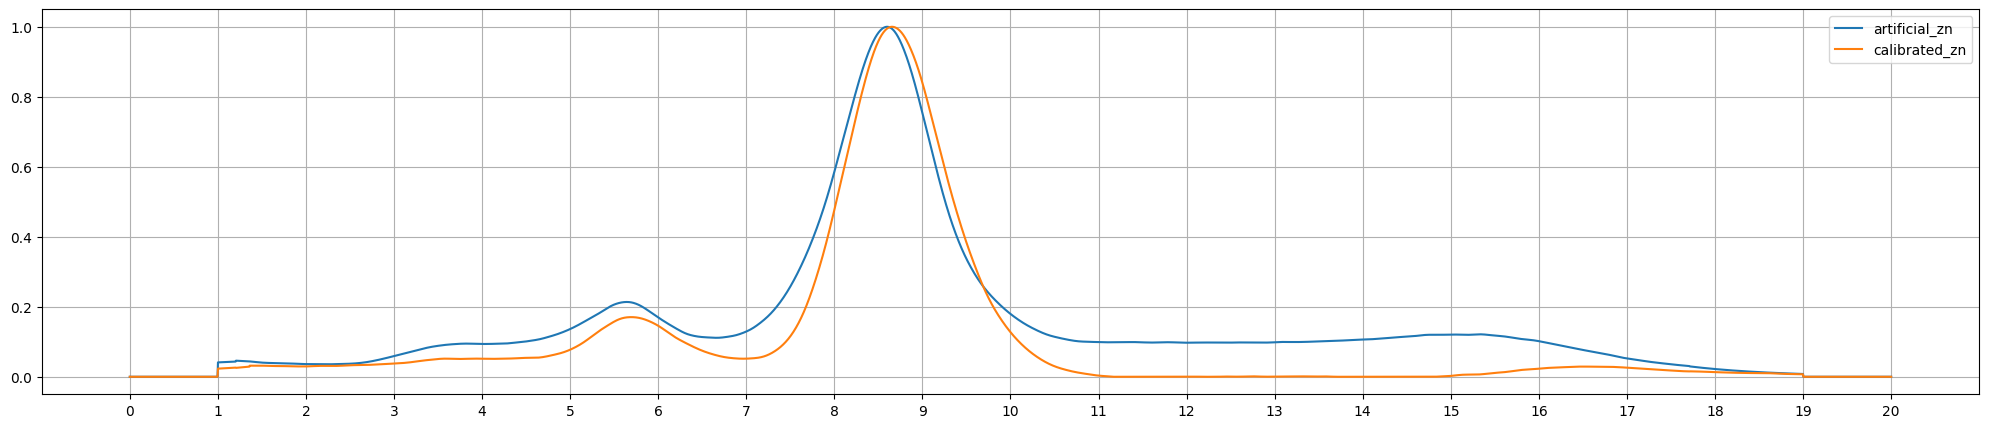

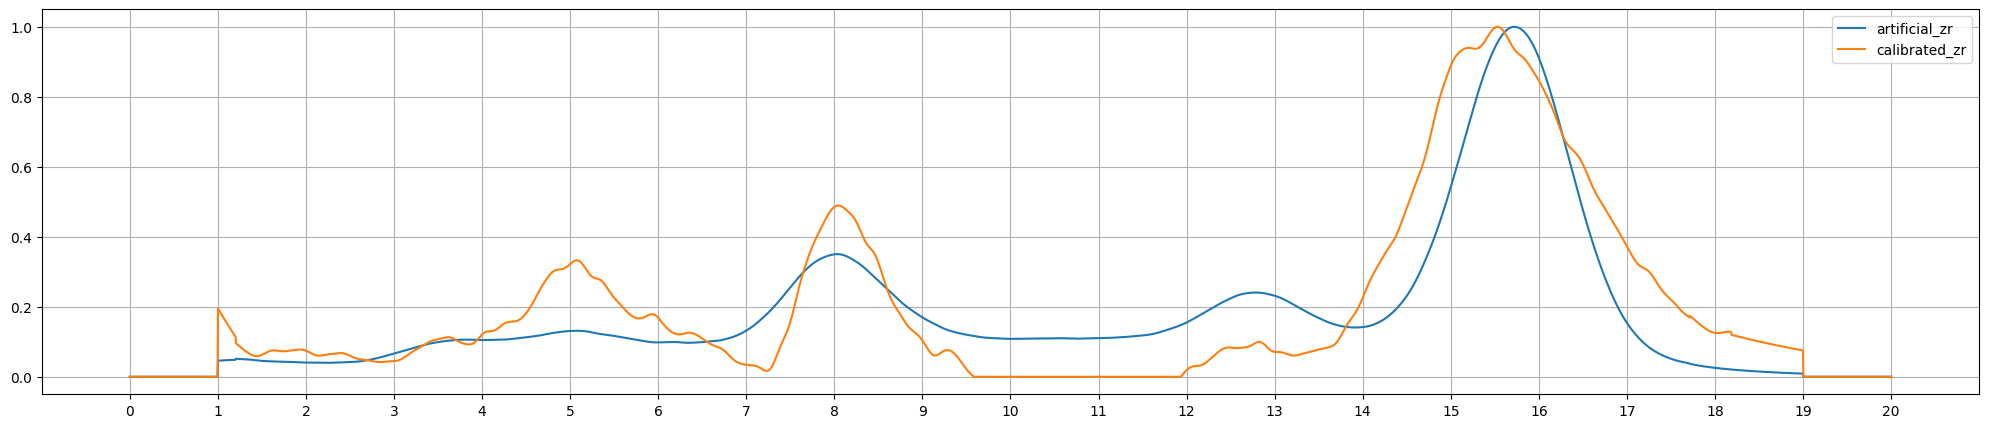

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from src.Elements import Elements

energy_range = np.linspace(0, 20, 4096)
wood_spectrum = np.load("data/objects/pigment_palette/1_calibrated_spectra.npz", allow_pickle=True)["wood"]
calibrated_spectra = np.load("data/objects/pigment_palette/2_subtracted_residual_spectra_heuristic.npz", allow_pickle=True)

for spectrum_name, spectrum in calibrated_spectra.items():
    if spectrum_name == "wood":
        continue

    artificial = np.zeros_like(energy_range)

    for element_name in spectrum_name.split("_"):
        artificial += ArtifficialTrainDataGenerator._generate_element_sample(np.linspace(0, 20, 4096), element_name, mu_err_global=0.00, mu_max_err=0.00, sigma_max_err=0.00, scale_sigma=1, cache_element_samples=False)


    artificial += wood_spectrum * 0.4
    artificial /= np.max(artificial)
    plt.figure(figsize=(25, 5))
    plt.plot(energy_range, artificial, label=f"artificial_{spectrum_name}")
    plt.plot(energy_range, spectrum, label=f"calibrated_{spectrum_name}")
    plt.xticks(np.arange(0, 21, 1))
    plt.legend()
    plt.grid(True)